# Seção 1 – Comparativo com modelos clássicos de séries temporais
**Pergunta:** a escolha de Ridge + LightGBM se sustenta frente aos modelos clássicos de previsão (ETS, SARIMAX, Prophet)?

**Protocolo idêntico ao do notebook 02:** mesmos dias de teste (4 janelas de 14 dias do walk-forward + holdout de 30 dias de junho),
previsão com 7 dias de antecedência (para prever o dia D usa só dados até D−7), mesmas métricas e alvo em log.

| Modelo | Ideia | Como foi configurado |
|---|---|---|
| **Naive sazonal** | Mesmo dia da semana, semana anterior | Sem parâmetros |
| **ETS (auto)** | Suavização exponencial com nível, tendência amortecida e sazonalidade semanal | Parâmetros otimizados pela biblioteca (erro de 1 passo) |
| **ETS (ajustado)** | Idem, sem tendência, com suavização escolhida para o erro de **7 passos** | α e γ escolhidos em grade nas 4 últimas semanas do treino de cada janela |
| **SARIMAX** | ARMA com sazonalidade semanal | Ordem escolhida por AIC só com dados anteriores à 1ª janela de teste |
| **SARIMAX (eventos)** | Idem, com variáveis de calendário/eventos como regressores | Mesma ordem; regressores sem variação no treino são descartados |
| **Prophet** | Tendência + sazonalidade semanal + efeitos de feriados/eventos | Sazonalidade anual desligada (só 8 meses); feriados e eventos com janelas |
| **Ridge, LightGBM, Média** | Modelos do notebook 02 (cenário A) | Mesmos parâmetros |

As previsões dos modelos clássicos levam ~8 min para serem geradas (reajuste a cada dia de teste); por isso ficam em cache em `reports/benchmark_*.csv`.

In [1]:
import json, sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from src.data import carregar, serie_diaria
from src import benchmarks as B
from src.viz import aplicar_estilo, salvar, milhoes, AZUL, LARANJA, AQUA, CINZA
aplicar_estilo()
d = serie_diaria(carregar())
RAIZ = Path('..')
ALVOS = {'receita_aprovada': 'Receita aprovada', 'nr_pedidos': 'Nº de pedidos'}
R, TAB, PRED = {}, {}, {}
for alvo in ALVOS:
    cache = RAIZ / 'reports' / f'benchmark_{alvo}.csv'
    if cache.exists():
        p = pd.read_csv(cache, index_col=0, parse_dates=True)
        yy = p.pop('real')
        meta = json.load(open(RAIZ / 'reports' / 'benchmark_meta.json'))[alvo]
        jan, n = [tuple(j) for j in meta['janelas']], meta['n']
    else:  # sem cache: recalcula (lento)
        p, yy, jan, n, _ = B.rodar(d[alvo])
    PRED[alvo] = (p, yy, jan, n)
    TAB[alvo] = B.resumir(p, yy, jan, n)

## Resultados – receita aprovada

In [2]:
TAB['receita_aprovada'].round(1).sort_values('WAPE walk-forward (%)')

,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Média Ridge+LGBM,24.2,30.1,32.7,477001.6,7.1
Ridge,25.1,30.0,32.4,474223.8,6.5
SARIMAX (eventos),25.2,29.6,31.9,469126.6,3.1
SARIMAX,25.6,30.2,32.6,478448.7,4.3
LightGBM,26.5,30.7,33.4,485493.0,7.6
ETS (ajustado),27.8,36.1,38.9,570657.2,6.0
Prophet,33.2,32.2,36.0,510264.8,13.3
ETS (auto),34.2,35.1,36.3,555403.6,-2.3
Naive sazonal,34.2,35.1,36.3,555337.5,-2.3


## Resultados – nº de pedidos

In [3]:
TAB['nr_pedidos'].round(1).sort_values('WAPE walk-forward (%)')

,WAPE walk-forward (%),WAPE holdout (%),MAPE holdout (%),MAE holdout,Viés holdout (%)
modelo,,,,,
Média Ridge+LGBM,27.3,27.5,32.8,4693.1,10.6
SARIMAX (eventos),27.8,25.2,29.8,4306.3,6.5
LightGBM,28.0,27.8,32.7,4745.2,10.8
SARIMAX,28.5,26.2,30.7,4467.6,8.3
Ridge,28.6,27.7,33.3,4721.1,10.4
ETS (ajustado),29.5,37.7,42.5,6435.4,7.5
Prophet,35.2,28.8,33.6,4922.2,11.0
ETS (auto),38.3,29.7,31.4,5060.2,-9.0
Naive sazonal,38.3,29.7,31.4,5060.2,-9.0


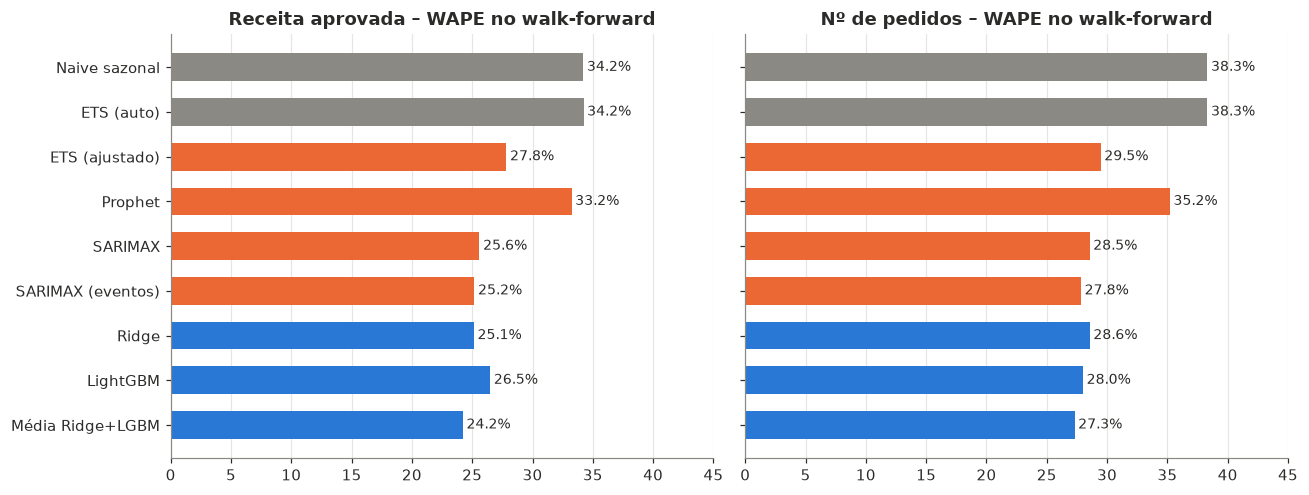

In [4]:
ordem = ['Naive sazonal', 'ETS (auto)', 'ETS (ajustado)', 'Prophet', 'SARIMAX', 'SARIMAX (eventos)', 'Ridge', 'LightGBM', 'Média Ridge+LGBM']
cor = {m: (CINZA if m in ('Naive sazonal', 'ETS (auto)') else AZUL if m in ('Ridge', 'LightGBM', 'Média Ridge+LGBM') else LARANJA) for m in ordem}
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, (alvo, nome) in zip(axs, ALVOS.items()):
    t = TAB[alvo].loc[ordem, 'WAPE walk-forward (%)']
    ax.barh(t.index[::-1], t.values[::-1], color=[cor[m] for m in t.index[::-1]], height=.62)
    for y_, v in enumerate(t.values[::-1]): ax.text(v + .3, y_, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'{nome} – WAPE no walk-forward'); ax.grid(axis='y', visible=False); ax.set_xlim(0, 45)
plt.tight_layout(); salvar(fig, '11_comparativo_modelos'); plt.show()

## Por que o "ETS (auto)" é idêntico ao baseline?
Não é erro de código. A biblioteca ajusta os parâmetros minimizando o erro de **1 passo à frente**; como a série é muito persistente
(autocorrelação de 0,77 em 1 dia), escolhe `smoothing_level = 1` (o nível é sempre o último valor observado) e sazonalidade fixa. Com período
sazonal de 7 e previsão a 7 dias, isso reduz-se matematicamente a "valor de 7 dias atrás" — exatamente o baseline. Para o horizonte que nos
interessa, é preciso escolher a suavização pelo erro de 7 passos, que é o que o "ETS (ajustado)" faz.

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
yl = np.log1p(d.nr_pedidos); o = 149
r = ExponentialSmoothing(yl.iloc[:o + 1], trend='add', damped_trend=True, seasonal='add', seasonal_periods=7).fit()
print('smoothing_level =', round(float(r.params['smoothing_level']), 3), '| smoothing_seasonal =', round(float(r.params['smoothing_seasonal']), 3))
print('previsão ETS(auto) a 7 dias:', round(float(np.expm1(r.forecast(7).iloc[-1]))), '| baseline (valor de 7 dias antes):', int(d.nr_pedidos.iloc[o]))

smoothing_level = 1.0 | smoothing_seasonal = 0.0
previsão ETS(auto) a 7 dias: 13668 | baseline (valor de 7 dias antes): 13668


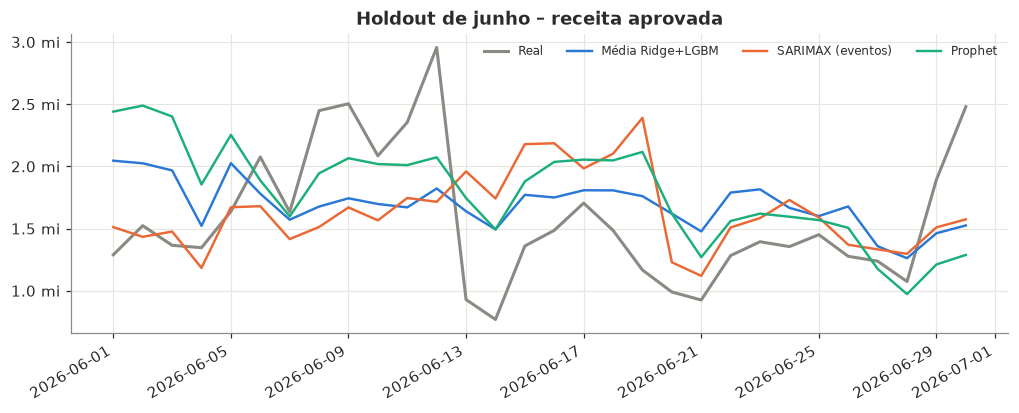

In [6]:
alvo = 'receita_aprovada'; p, yy, jan, n = PRED[alvo]
ho = p.index[n - jan[0][0]:]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ho, yy.loc[ho], color=CINZA, label='Real')
for m, c in [('Média Ridge+LGBM', AZUL), ('SARIMAX (eventos)', LARANJA), ('Prophet', AQUA)]:
    ax.plot(ho, p.loc[ho, m], color=c, lw=1.6, label=m)
ax.yaxis.set_major_formatter(FuncFormatter(milhoes)); ax.set_title('Holdout de junho – receita aprovada'); ax.legend(ncol=4, fontsize=8)
fig.autofmt_xdate(); salvar(fig, '12_comparativo_holdout'); plt.show()

## Conclusões
1. **Quem fica no topo (receita e pedidos):** a média Ridge+LightGBM e o **SARIMAX com eventos** estão empatados. As diferenças são de ~1 ponto de WAPE
   (receita: 24,2% × 25,2% no walk-forward; pedidos: 27,3% × 27,8%), pequenas demais para um teste de 56 dias + 30 dias; o holdout até inverte a ordem em alguns casos. **Não dá para afirmar que um seja melhor que o outro.**
2. **ETS (auto) = baseline**, por construção (explicado acima). O **ETS (ajustado)** melhora no walk-forward (27,8% na receita), mas **piora no holdout** (36,1% contra 35,1% do baseline): instável.
3. **Prophet** fica perto do baseline (33,2% e 35,2% no walk-forward) e com viés positivo de ~13% na receita no holdout. Provável causa: usa
   sazonalidade semanal fixa e tendência, sem o nível recente das últimas semanas; com 8 meses, a Black Friday também distorce a tendência. Uma sazonalidade anual não é estimável com este histórico.
4. **O que explica o ganho dos melhores:** todos que ficam à frente do baseline combinam **dois ingredientes**: o nível/padrão recente (lags, parte autorregressiva) e os eventos de calendário. Nenhum modelo, clássico ou de ML, ultrapassa ~24–25% de WAPE na receita: o limite vem da informação (campanhas fora do calendário), não do algoritmo.
5. **Por que manter Ridge + LightGBM:** desempenho equivalente ao melhor clássico, flexibilidade para incluir variáveis novas (calendário comercial, mídia) sem as premissas de estacionariedade do SARIMAX, e importância de variáveis comparável entre modelos. **Mas a justificativa é de conveniência e extensibilidade, não de superioridade medida.**
6. **Limites desta comparação:** (a) ordem do SARIMAX escolhida por AIC em dados anteriores ao teste, mas poucas combinações foram exploradas; (b) os clássicos são reajustados a cada dia de teste, enquanto o ML é treinado uma vez por janela, o que é uma vantagem para os clássicos; (c) não testamos modelos globais por categoria nem redes neurais, pelo volume de dados.

In [7]:
R['tabelas'] = {a: TAB[a].round(1).to_dict('index') for a in TAB}
R['ordem_sarimax'] = json.load(open(RAIZ / 'reports' / 'benchmark_meta.json'))
json.dump(R, open(RAIZ / 'reports' / 'resultados_benchmark.json', 'w'), ensure_ascii=False, indent=2, default=str)